#Imports e downloads

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/Projeto_est/full_filled_stroke_data (1).csv")
dataset.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1


#Análise exploratória

Primeiramente iremos conferir se existe algum valor inválido no nosso dataset

In [ ]:
dataset.columns[dataset.isna().any()]

Index([], dtype='object')

Como não foi encontrado nenhum, agora será feita a transformação dos atributos que estão como palavras para inteiros

Checando os possíveis valores da coluna ***gender***

In [ ]:
dataset.gender.unique()

array(['Female', 'Male'], dtype=object)

Mapeando ***gender***:
   - Female --> 0
   - Male --> 1

In [ ]:
# trocando Female/Male para string '0'/ '1'
dataset['gender'] = dataset['gender'].apply(lambda x: str(x).replace("Female","0"))
dataset['gender'] = dataset['gender'].apply(lambda x: str(x).replace("Male","1"))

#transformando srting '0'/'1' nos números 0/1

dataset['gender'] = dataset['gender'].astype('int64')

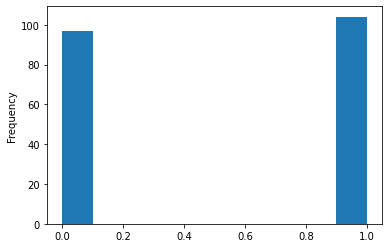

In [ ]:
dataset['gender'].plot(kind = 'hist')

Checando os possíveis valores da coluna ***ever_married***

In [ ]:
dataset.ever_married.unique()

array(['Yes', 'No'], dtype=object)

Mapeando ***ever_married***:
- No --> 0
- Yes --> 1

In [ ]:
# trocando No/Yes para string '0'/ '1'
dataset['ever_married'] = dataset['ever_married'].apply(lambda x: str(x).replace("No","0"))
dataset['ever_married'] = dataset['ever_married'].apply(lambda x: str(x).replace("Yes","1"))

#transformando srting '0'/'1' nos números 0/1

dataset['ever_married'] = dataset['ever_married'].astype('int64')

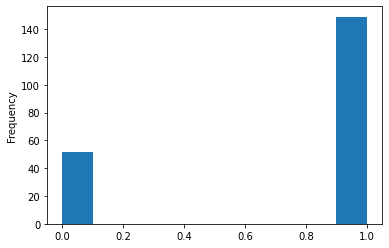

In [ ]:
dataset['ever_married'].plot(kind = 'hist')

Checando os possíveis valores da coluna ***work_type***

In [ ]:
dataset.work_type.unique()

array(['Self-employed', 'Private', 'Govt_job', 'children'], dtype=object)

Mapeando ***work_type***:
- Self-employed -->  0
- Private -->  1
- Govt_job -->  2
- children -->  3

In [ ]:
# mapeando as strings para seus respectivos 'inteiros'
dataset['work_type'] = dataset['work_type'].apply(lambda x: str(x).replace("Self-employed","0"))
dataset['work_type'] = dataset['work_type'].apply(lambda x: str(x).replace("Private","1"))
dataset['work_type'] = dataset['work_type'].apply(lambda x: str(x).replace("Govt_job","2"))
dataset['work_type'] = dataset['work_type'].apply(lambda x: str(x).replace("children","3"))

#transformando as strings em inteiros

dataset['work_type'] = dataset['work_type'].astype('int64')

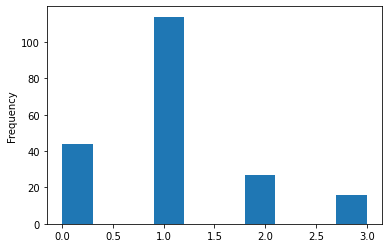

In [ ]:
dataset['work_type'].plot(kind = 'hist')

Checando os possíveis valores da coluna ***Residence_type***

In [ ]:
dataset.Residence_type.unique()

array(['Rural', 'Urban'], dtype=object)

Mapeando ***Residence_type***:
- Rural --> 0
- Urban --> 1

In [ ]:
# trocando Rural/Urban para string '0'/ '1'
dataset['Residence_type'] = dataset['Residence_type'].apply(lambda x: str(x).replace("Rural","0"))
dataset['Residence_type'] = dataset['Residence_type'].apply(lambda x: str(x).replace("Urban","1"))

#transformando string '0'/'1' nos números 0/1

dataset['Residence_type'] = dataset['Residence_type'].astype('int64')

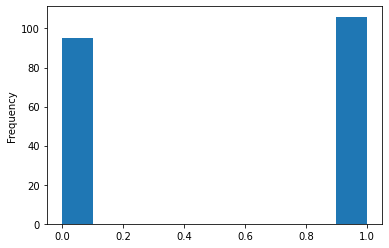

In [ ]:
dataset['Residence_type'].plot(kind = 'hist')

Checando os possíveis valores da coluna ***smoking_status***

In [ ]:
dataset.smoking_status.unique()

array(['never smoked', 'Unknown', 'formerly smoked', 'smokes'],
      dtype=object)

Mapeando ***smoking_status***:
- Unknown --> 0
- never smoked --> 1
- formerly smoked --> 2
- smokes --> 3

In [ ]:
# mapeando as strings para seus respectivos 'inteiros'
dataset['smoking_status'] = dataset['smoking_status'].apply(lambda x: str(x).replace("Unknown","0"))
dataset['smoking_status'] = dataset['smoking_status'].apply(lambda x: str(x).replace("never smoked","1"))
dataset['smoking_status'] = dataset['smoking_status'].apply(lambda x: str(x).replace("formerly smoked","2"))
dataset['smoking_status'] = dataset['smoking_status'].apply(lambda x: str(x).replace("smokes","3"))

# transformando as strings em inteiros

dataset['smoking_status'] = dataset['smoking_status'].astype('int64')

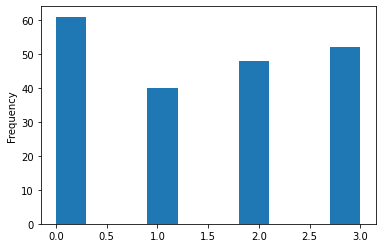

In [ ]:
dataset['smoking_status'].plot(kind = 'hist')

> Matriz de relaçao de dependência

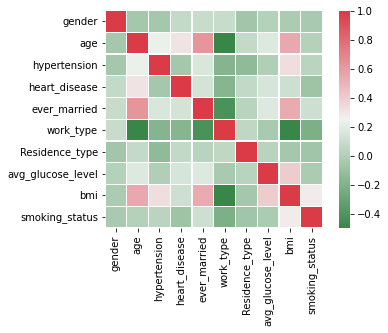

In [ ]:
corr = dataset.iloc[:,:-1].corr(method="pearson")
cmap = sns.diverging_palette(133, 10, as_cmap=True)
sns.heatmap(corr, vmax=1, vmin=-.5, cmap=cmap, square=True, linewidths=.2)

Como podemos observar, a feature 'ever_married' tem uma relação relativamente forte com a feature 'age', portanto, decidimos remove-la

In [ ]:
dataset = dataset.drop(columns = 'ever_married')
outros = dataset
dataset.head()

,gender,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,61.0,0,0,0,0,202.21,31.555602,1,1
1,0,59.0,0,0,1,0,76.15,30.242937,0,1
2,1,78.0,0,1,1,1,219.84,30.698951,0,1
3,1,57.0,0,1,2,1,217.08,33.808410,0,1
4,1,58.0,0,0,1,0,189.84,31.378534,0,1


In [ ]:
dataset.describe()

,gender,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.517413,52.049154,0.233831,0.164179,1.074627,0.527363,126.724627,29.336870,1.452736,0.199005
std,0.500944,22.276181,0.424323,0.371363,0.818171,0.500497,59.240322,3.363098,1.174310,0.400249
min,0.000000,0.480000,0.000000,0.000000,0.000000,0.000000,57.520000,17.899295,0.000000,0.000000
25%,0.000000,37.000000,0.000000,0.000000,1.000000,0.000000,81.430000,28.397893,0.000000,0.000000
50%,1.000000,58.000000,0.000000,0.000000,1.000000,1.000000,99.870000,29.948147,1.000000,0.000000
75%,1.000000,71.000000,0.000000,0.000000,1.000000,1.000000,191.790000,31.378534,3.000000,0.000000
max,1.000000,82.000000,1.000000,1.000000,3.000000,1.000000,260.850000,35.188605,3.000000,1.000000


##Avaliando importância das features


In [ ]:
df = dataset
X = df.drop(columns = 'stroke') # features da nossa base
Y = dataset['stroke'] # 'alvo' da nossa base

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state = 20)

In [ ]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid = {'criterion' : ['gini', 'entropy'], 'min_samples_split':[2, 5, 10, 30, 40]},
                         cv = 6).fit(X_train, Y_train)

print(grid_tree.best_estimator_)

DecisionTreeClassifier(min_samples_split=30)


In [ ]:
tree = grid_tree.best_estimator_
tree.score(X_test, Y_test)

0.7843137254901961

In [ ]:
features_names = X.columns
features_names

Index(['gender', 'age', 'hypertension', 'heart_disease', 'work_type',
       'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status'],
      dtype='object')

In [ ]:
importance = np.array(sorted(list (zip ( features_names, np.round(tree.feature_importances_, 3))), key = lambda x :x[1]))
importance

array([['gender', '0.0'],
       ['heart_disease', '0.0'],
       ['work_type', '0.0'],
       ['Residence_type', '0.0'],
       ['smoking_status', '0.0'],
       ['hypertension', '0.071'],
       ['avg_glucose_level', '0.182'],
       ['bmi', '0.23'],
       ['age', '0.517']], dtype='<U32')

Podemos ver a relevância, nessa separação dos dados, dos parâmetros contínuos(bmi, avg_glucose_level, age) , por isso decidimos utilizar o classificador ingênuo de bayes gaussiando para checar se é possível atingir um resultado satisfatório apenas com essas features.

#Treinamento e validação

Primeiro iremos utilizar o classifcador gaussiando ingênuo de bayes, para isso, devemos remover todos os parâmetros que não são contínuos do nosso dataset. Além disso, também iremos remover o atributo bmi, uma vez que ele não se mostrou relevante, nessa divisão dos dados, para o diagnóstico de um AVC.

In [ ]:
gauss = dataset
gauss = gauss.drop(columns = 'gender')
gauss = gauss.drop(columns = 'heart_disease')
gauss = gauss.drop(columns = 'work_type')
gauss = gauss.drop(columns = 'Residence_type')
gauss = gauss.drop(columns = 'smoking_status')
gauss = gauss.drop(columns = 'hypertension' )
gauss.head()

,age,avg_glucose_level,bmi,stroke
0,61.0,202.21,31.555602,1
1,59.0,76.15,30.242937,1
2,78.0,219.84,30.698951,1
3,57.0,217.08,33.808410,1
4,58.0,189.84,31.378534,1


iremos agora separar o nosso dataset de treino e teste


In [ ]:
train_gauss, test_gauss = train_test_split(gauss,test_size = .3, random_state=20)

 Iremos assumir que as features utilizadas seguem uma distribuição normal. Partindo desse pressuposto, a probabilidade de um parâmetro pertencer a uma classe(teve AVC, ou não teve AVC) vai ser dada pela equação da distribuição normal parametrizada por M, média da feature dado que ela pertence a classe X(teve ou não teve AVC), e V, variância da feature dado que ela pertence a classe X

In [ ]:
def likelihood_gaussiano(df, nome_parametro, valor_par, avc):

    df = df[df['stroke']==avc]
    media = df[nome_parametro].mean()
    variancia = df[nome_parametro].std()
    p_x_given_y = (1 / (np.sqrt(2 * np.pi) * variancia)) *  np.exp(-((valor_par - media)**2 / (2 * variancia**2 )))


    return p_x_given_y

In [ ]:
def naive_bayes_gaussiano(df, teste):

    features = list(df.columns)[:-1] # nome das features


    prob_avc = len(df[df['stroke'] == 1])/len(df) #probablidade de uma pessoa da nossa base de treino ter tido um avc
    prob_Navc = 1 - prob_avc # probabilidade de uma pessoa da nossa base de treino nao ter tido um avc
    predicoes = [] #array de predições inicialmente vazio


    for t in teste:

        p_stroke = 1
        p_no_stroke = 1
        for i in range(len(features)):
         # print(features[i])
          p_stroke = p_stroke* likelihood_gaussiano(df, features[i], t[i], 1) # P(t[i] | stroke == 1)
          p_no_stroke = p_no_stroke * likelihood_gaussiano(df, features[i], t[i], 0) # P(t[i] | stroke == 0)

        final_avc = p_stroke * prob_avc  #P(stroke == 1 | t)
        final_Navc = p_no_stroke * prob_Navc # P(stroke == 0 | t)
        #print(f'final_avc : {final_avc}\n final_Navc = {final_Navc}')

        if final_avc > final_Navc:
          predicoes.append(1)
        else :
          predicoes.append(0)



    return np.array(predicoes)

Treinando e testando o classificador ingenuo de bayes gaussiano

In [ ]:
xteste = test_gauss.iloc[:,:-1].values
yteste = test_gauss.iloc[:,-1].values

Y_pred = naive_bayes_gaussiano(train_gauss, xteste)

acertos = 0
tp =0
tn = 0
fp =0
fn =0
for i in range(len(yteste)):
  if Y_pred[i] == yteste[i]:
    if Y_pred[i] == 0:
      tn+=1
    else:
      tp+=1
    acertos+=1
  else:
    if Y_pred[i] == 0:
      fn+=1
    else:
      fp+=1
acc = acertos/len(yteste)
print(f'true_positive: {tp}\ntrue_negative: {tn}\nfalse_positive: {fp} \nfalse_negative: {fn}')
print('Accuracy = ', acc)

true_positive: 5
true_negative: 48
false_positive: 5 
false_negative: 3
Accuracy =  0.8688524590163934


Comparando o nosso classificador  com o classificador ingenuo de bayes gaussiano importado

In [ ]:

gnb = GaussianNB()

X_train2 = train_gauss.iloc[:,:-1].values
Y_train2 = train_gauss.iloc[:,-1].values

gnb.fit(X_train2, Y_train2)

ypred = gnb.predict(xteste)

acertos_gnb =0
tp_gnb =0
tn_gnb = 0
fp_gnb = 0
fn_gnb = 0
for i in range(len(yteste)):
  if ypred[i] == yteste[i]:
    if ypred[i] == 0:
      tn_gnb+=1
    else:
      tp_gnb+=1
    acertos_gnb+=1
  else:
    if ypred[i] == 0:
      fn_gnb+=1
    else:
      fp_gnb+=1
acc3 = acertos_gnb/len(yteste)
print(f'true_positive: {tp_gnb}\ntrue_negative: {tn_gnb}\nfalse_positive: {fp_gnb} \nfalse_negative: {fn_gnb}')
print('Accuracy = ', acc3)

true_positive: 5
true_negative: 47
false_positive: 6 
false_negative: 3
Accuracy =  0.8524590163934426


O ponto positivo do nosso classificador foi que houveram poucos casos de falso negativo, a classificação mais perigosa. Agora iremos aplicar o classifcador ingenuo de bayes categorico a fim de comparar os resultados. .



In [ ]:
categorico = dataset
categorico

,gender,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,61.0,0,0,0,0,202.21,31.555602,1,1
1,0,59.0,0,0,1,0,76.15,30.242937,0,1
2,1,78.0,0,1,1,1,219.84,30.698951,0,1
3,1,57.0,0,1,2,1,217.08,33.808410,0,1
4,1,58.0,0,0,1,0,189.84,31.378534,0,1
...,...,...,...,...,...,...,...,...,...,...
196,1,41.0,0,0,1,0,70.15,29.756631,2,0
197,1,40.0,0,0,1,1,191.15,31.124172,3,0
198,0,45.0,1,0,2,0,95.02,31.798304,3,0
199,1,40.0,0,0,1,0,83.94,29.951301,3,0


Mapeando ***Body Mass Index(bmi)***:
- bmi < 18.5 --> classe 0 (abaixo do peso)
- 18.5 <= bmi < 25 --> classe 1 (normal)
- 25 <= bmi < 30 --> classe 2 (acima do peso)
- bmi >= 30 --> classe 3 (obeso)

Fonte: https://www.cdc.gov/obesity/basics/adult-defining.html#:~:text=Adult%20Body%20Mass%20Index&text=If%20your%20BMI%20is%20less,falls%20within%20the%20obesity%20range.


In [ ]:
def classificar_bmi(x):
  resp = 0
  if x < 18.5:
    resp = 0
  elif  x < 25:
    resp = 1
  elif x< 30:
    resp = 2
  else:
    resp = 3

  return resp

In [ ]:
# aplicando a classificação
categorico['bmi'] = categorico['bmi'].apply(lambda x: classificar_bmi(x))

categorico['bmi']

0      3
1      3
2      3
3      3
4      3
      ..
196    2
197    3
198    3
199    2
200    2
Name: bmi, Length: 201, dtype: int64

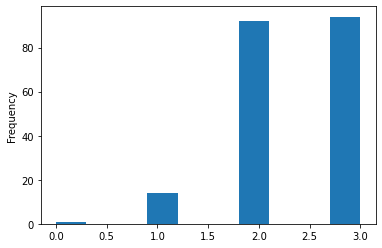

In [ ]:
categorico['bmi'].plot(kind = 'hist')

Mapeando ***avg_glucose level***:
- avg_glucose level < 100 --> classe 0 (normal)
- 100 <= avg_glucose level < 126 --> classe 1 (pré diabético)
- avg_glucose level >= 126 --> classe 2 (diabético)

Fonte: https://www.cdc.gov/diabetes/basics/getting-tested.html#:~:text=A%20fasting%20blood%20sugar%20level,higher%20indicates%20you%20have%20diabetes.


In [ ]:
def classificar_avg_glucose_level(x):
  resp = 0
  if x < 100:
    resp = 0
  elif x < 126:
    resp = 1
  else:
    resp = 2

  return resp

In [ ]:
categorico['avg_glucose_level'] = categorico['avg_glucose_level'].apply(lambda x: classificar_avg_glucose_level(x))

categorico['avg_glucose_level']

0      2
1      0
2      2
3      2
4      2
      ..
196    0
197    2
198    0
199    0
200    0
Name: avg_glucose_level, Length: 201, dtype: int64

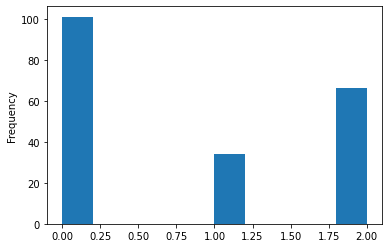

In [ ]:
categorico['avg_glucose_level'].plot(kind = 'hist')

Mapeando ***age***:
- age <= 14 --> classe 0 (criança)
- 14 < age <= 25 --> classe 1 (jovem)
- 25 < age <= 64 --> classe 2 (adulto)
- age > 64 --> classe 3 (idoso)

In [ ]:
def classificar_age(x):
  if x <= 14:
    resp = 0
  elif x <= 25:
    resp = 1
  elif x <= 64:
    resp = 2
  else:
    resp = 3

  return resp


In [ ]:
categorico['age'] = categorico['age'].apply(lambda x: classificar_age(x))

categorico['age']

0      2
1      2
2      3
3      2
4      2
      ..
196    2
197    2
198    2
199    2
200    3
Name: age, Length: 201, dtype: int64

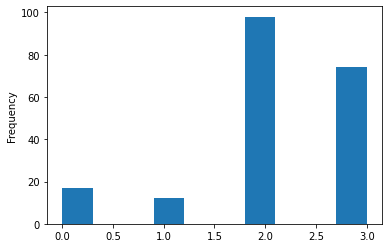

In [ ]:
categorico['age'].plot(kind = 'hist')

Agora nosso dataset *categorico* está pronto para ser utilizado em um classficador ingênuo de bayes categórico

Separando os datasets de treino e teste(divisão diferente da feita com o classificador gaussiano)

In [ ]:
train_categoric, test_categoric = train_test_split(categorico, random_state=150)

 A implementação do nosso modelo foi feita utilizando os conceitos básicos do teorema de Bayes. Para todas as características de uma pessoa da nossa base, iremos calcular a probabilidade desse atributo pertencer a uma classe X( teve AVC ou não teve AVC) através da fórmula de probabilidade condicional de Bayes. Como assumimos que todos os parâmetros são independentes, uma vez que se trata do classificado ingênuo,  o resultado para cada uma das features é multiplicado, e no fim, é feito o produto dessa resposta com a probabilidade de uma pessoa qualquer da nossa base pertencer a uma classe X.


In [ ]:
def p_x_dado_avc(df, nome_feature, valor, avc):

    df = df[df['stroke']==avc] # deixando no dataset 'df' apenas as pessoas que (avc == 1 ? tiveram : nao tiveram) um stroke

    p_x_given_y = (len(df[df[nome_feature]==valor]))/ len(df) #das pessoas que (avc == 1 ? tiveram : nao tiveram) um stroke, qual a probabilidade
                                                              # de ela ter a feature NOME_FEATURE com o valor VALOR?
    return p_x_given_y

In [ ]:
def naive_bayes_categorico(df, teste):

    features = list(df.columns)[:-1] # nome das features


    prob_avc = len(df[df['stroke'] == 1])/len(df) #probablidade de uma pessoa da nossa base ter tido um avc
    prob_Navc = 1 - prob_avc # probabilidade de uma pessoa da nossa base nao ter tido um avc

    predicoes = [] #array de predições inicialmente vazio


    for t in teste:

        p_stroke = 1
        p_no_stroke = 1
        for i in range(len(features)):
          p_stroke = p_stroke* p_x_dado_avc(df, features[i], t[i], 1) # P(t[i] | stroke == 1)
          p_no_stroke = p_no_stroke * p_x_dado_avc(df, features[i], t[i], 0) # P(t[i] | stroke == 0)

        final_avc = p_stroke * prob_avc #P(stroke == 1 | t)
        final_Navc = p_no_stroke * prob_Navc # P(stroke == 0 | t)

        if final_avc > final_Navc:
          predicoes.append(1)
        else :
          predicoes.append(0)



    return np.array(predicoes)

In [ ]:
xtestec = test_categoric.iloc[:,:-1].values
ytestec = test_categoric.iloc[:,-1].values

Y_predc = naive_bayes_categorico(train_categoric, xtestec)

rightc = 0
tpc =0
tnc = 0
fpc =0
fnc =0
for i in range(len(ytestec)):
  if Y_predc[i] == ytestec[i]:
    if Y_predc[i] == 0:
      tnc+=1
    else:
      tpc+=1
    rightc+=1
  else:
    if Y_predc[i] == 0:
      fnc+=1
    else:
      fpc+=1

print(f'true_positive: {tpc}\ntrue_negative: {tnc}\nfalse_positive: {fpc} \nfalse_negative: {fnc}')
print('Accuracy = ', rightc/len(ytestec))

true_positive: 4
true_negative: 37
false_positive: 6 
false_negative: 4
Accuracy =  0.803921568627451


In [ ]:
cnb = CategoricalNB()

X_train2 = train_categoric.iloc[:,:-1].values
Y_train2 = train_categoric.iloc[:,-1].values

X_test2 = test_categoric.iloc[:,:-1].values
Y_test2 = test_categoric.iloc[:,-1].values

cnb.fit(X_train2, Y_train2)
ypredc = cnb.predict(X_test2)
acertos_cnb = 0
tp_cnb =0
tn_cnb = 0
fp_cnb =0
fn_cnb =0
for i in range(len(Y_test2)):
  if ypredc[i] == Y_test2[i]:
    if ypredc[i] == 0:
      tn_cnb+=1
    else:
      tp_cnb+=1
    acertos_cnb+=1
  else:
    if ypredc[i] == 0:
      fn_cnb+=1
    else:
      fp_cnb+=1
print(f'true_positive: {tp_cnb}\ntrue_negative: {tn_cnb}\nfalse_positive: {fp_cnb} \nfalse_negative: {fn_cnb}')
print('Accuracy = ', acertos_cnb/len(ypredc))

true_positive: 4
true_negative: 38
false_positive: 5 
false_negative: 4
Accuracy =  0.8235294117647058


resultados não estão satisfatórios, uma vez que 80% da nossa base não tem AVC, iremos agora testar se não tem alguma feature que seja irrelevante para o diagnostico que esteja atrapalhando o resultado

In [ ]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid = {'criterion' : ['gini', 'entropy'], 'min_samples_split':[2, 5, 10, 30, 40]},
                         cv = 6).fit(X_train2, Y_train2)

print(grid_tree.best_estimator_)

DecisionTreeClassifier(min_samples_split=30)


In [ ]:
tree = grid_tree.best_estimator_
tree.score(X_test2, Y_test2)

0.803921568627451

In [ ]:
importance = np.array(sorted(list (zip ( features_names, np.round(tree.feature_importances_, 3))), key = lambda x :x[1]))
importance

array([['work_type', '0.0'],
       ['Residence_type', '0.006'],
       ['smoking_status', '0.063'],
       ['gender', '0.071'],
       ['avg_glucose_level', '0.077'],
       ['hypertension', '0.082'],
       ['heart_disease', '0.143'],
       ['bmi', '0.235'],
       ['age', '0.324']], dtype='<U32')

Removendo os atributos menos relevantes

In [ ]:
categoric_2 = categorico
categoric_2 = categoric_2.drop(columns = 'work_type')
categoric_2 = categoric_2.drop(columns = 'Residence_type')
categoric_2.head()

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
0,0,2,0,0,2,3,1,1
1,0,2,0,0,0,3,0,1
2,1,3,0,1,2,3,0,1
3,1,2,0,1,2,3,0,1
4,1,2,0,0,2,3,0,1


In [ ]:
treino_categoric2, teste_categoric2 = train_test_split(categoric_2, random_state=150)

In [ ]:
xtestec2 = teste_categoric2.iloc[:,:-1].values
ytestec2 = teste_categoric2.iloc[:,-1].values

Y_predc2 = naive_bayes_categorico(treino_categoric2, xtestec2)

acertos2 = 0
tpc2 =0
tnc2 = 0
fpc2 =0
fnc2 =0
for i in range(len(ytestec2)):
  if Y_predc2[i] == ytestec2[i]:
    if Y_predc2[i] == 0:
      tnc2+=1
    else:
      tpc2+=1
    acertos2+=1
  else:
    if Y_predc2[i] == 0:
      fnc2+=1
    else:
      fpc2+=1

print(f'true_positive: {tpc2}\ntrue_negative: {tnc2}\nfalse_positive: {fpc2} \nfalse_negative: {fnc2}')
print('Accuracy = ', acertos2/len(ytestec2))

true_positive: 5
true_negative: 38
false_positive: 5 
false_negative: 3
Accuracy =  0.8431372549019608


In [ ]:

cnb = CategoricalNB()

X_train2 = treino_categoric2.iloc[:,:-1].values
Y_train2 = treino_categoric2.iloc[:,-1].values

X_test2 = teste_categoric2.iloc[:,:-1].values
Y_test2 = teste_categoric2.iloc[:,-1].values


cnb.fit(X_train2, Y_train2)

ypredc = cnb.predict(X_test2)


acertos_cnb = 0
tp_cnb =0
tn_cnb = 0
fp_cnb =0
fn_cnb =0
for i in range(len(Y_test2)):
  if ypredc[i] == Y_test2[i]:
    if ypredc[i] == 0:
      tn_cnb+=1
    else:
      tp_cnb+=1
    acertos_cnb+=1
  else:
    if ypredc[i] == 0:
      fn_cnb+=1
    else:
      fp_cnb+=1
print(f'true_positive: {tp_cnb}\ntrue_negative: {tn_cnb}\nfalse_positive: {fp_cnb} \nfalse_negative: {fn_cnb}')
print('Accuracy = ', acertos_cnb/len(ypredc))

true_positive: 5
true_negative: 40
false_positive: 3 
false_negative: 3
Accuracy =  0.8823529411764706


#Testando outros classificadores

In [ ]:

f2 = outros
fX = f2.drop(columns = 'stroke')
fY = outros['stroke']
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(fX, fY, random_state = 20)
outros

,gender,age,hypertension,heart_disease,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,61.0,0,0,0,0,202.21,31.555602,1,1
1,0,59.0,0,0,1,0,76.15,30.242937,0,1
2,1,78.0,0,1,1,1,219.84,30.698951,0,1
3,1,57.0,0,1,2,1,217.08,33.808410,0,1
4,1,58.0,0,0,1,0,189.84,31.378534,0,1
...,...,...,...,...,...,...,...,...,...,...
196,1,41.0,0,0,1,0,70.15,29.756631,2,0
197,1,40.0,0,0,1,1,191.15,31.124172,3,0
198,0,45.0,1,0,2,0,95.02,31.798304,3,0
199,1,40.0,0,0,1,0,83.94,29.951301,3,0


##Floresta randômica

In [ ]:

from sklearn.ensemble import RandomForestClassifier


rfc = RandomForestClassifier(random_state=0, n_estimators=10)

rfc.fit(X_train_f, y_train_f)

y_pred_f = rfc.predict(X_test_f)


print('Acuracia Floresta Randômica = ', format(metrics.accuracy_score(y_test_f, y_pred_f)))


Acuracia Floresta Randômica =  0.8431372549019608


##kNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 20)
knn_model.fit(X_train_f, y_train_f)

y_pred = knn_model.predict(X_test_f)

print('Acuracia kNN  =' , metrics.accuracy_score(y_test_f, y_pred))


Acuracia kNN  = 0.8823529411764706


##Regressão Logística

In [ ]:
lg_model = LogisticRegression()

lg_model = lg_model.fit(X_train_f, y_train_f)

ypred = lg_model.predict(X_test_f)

print('Acuracia Regressão Logística  =' , metrics.accuracy_score(y_test_f, y_pred))

Acuracia Regressão Logística  = 0.8823529411764706


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
